# 06 · Are the tide and the currents related?

We have two co-located instruments at the same site: a **pressure gauge** (the
tide / sea level, notebooks 00–04) and a **current meter** (water velocity,
notebook 05). The same Moon-and-Sun tide drives *both*, so they ought to be
related — but *how* exactly? This notebook runs several complementary tests on
the **overlapping period** where both recorded.

We'll move from "do they look related?" to "they are coherent at the tidal
frequencies, and the current leads the tide by ~X hours" — a quantitative answer.

> 🎯 **What you'll learn in this notebook**
>
> - Combine pressure and current onto one aligned hourly time base
> - Reduce the vector current to its main axis (the tidal-current direction)
> - Test relatedness with: overlay, lagged cross-correlation, coherence spectrum
> - Measure the phase lag between tide and current per constituent (harmonic)
> - Interpret the lag physically (progressive vs standing tidal wave)

## The physics, briefly

Think of the tide as a wave. There are two textbook end-members:

* **Progressive wave** (like a wave rolling across open water): the current is
  **strongest at high and low tide** and slack in between — current and elevation
  are *in phase* (0° apart).
* **Standing wave** (sloshing in a basin): the current is **strongest at
  mid-tide** and slack at the extremes — current and elevation are *90° apart*
  (in "quadrature").

Real coasts are a mix. So the **phase lag** we measure between pressure and
current is physically meaningful — it tells us which behaviour dominates here.

> 📖 **In phase / quadrature** — two oscillations are 'in phase' when their peaks line up (0°), 'in quadrature' when one peaks while the other is at zero (90°). Tidal elevation vs current sits somewhere between, depending on the wave type.

> 📖 **Coherence** — a frequency-by-frequency correlation (0–1). High coherence at a frequency means the two signals move together there — even if elsewhere they don't. The tidal test: is coherence high at the diurnal & semidiurnal bands?

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


In [2]:
STATION = ol.primary_current_station()       # station with both current + pressure
win = ol.current_window(STATION)
a, b = win["start"], win["end"]
print(f"Station {STATION}, window {a} → {b}")

cur = ol.load_current(STATION, a, b, rule="1h")              # current (m/s), hourly, QC'd
press = ol.load_decimated(STATION, "pressure", a, b, rule="1h")  # pressure (dbar), hourly

df = pd.concat({"press": press, "east": cur["east"], "north": cur["north"]}, axis=1).dropna()
print(f"{len(df)} hours where BOTH instruments have good data "
      f"({df.index[0].date()} → {df.index[-1].date()})")

Station HYSB1, window 2018-10-02 → 2019-04-19


4712 hours where BOTH instruments have good data (2018-10-02 → 2019-04-19)


## Step 1 · Reduce the current to one number: the tidal-current axis

The current is a 2-D vector, but tidal currents mostly oscillate **back and forth
along one axis**. We find that axis with a quick principal-component analysis
(`ol.principal_axis`) and project the current onto it — giving a single scalar
"along-axis current" we can compare directly with the tide.

Tidal-current axis orientation: 2° from North (unit vector east=0.04, north=1.00)
saved /Users/quakehunter/Documents/data_exploration/figures/06_HYSB1_principal_axis.png


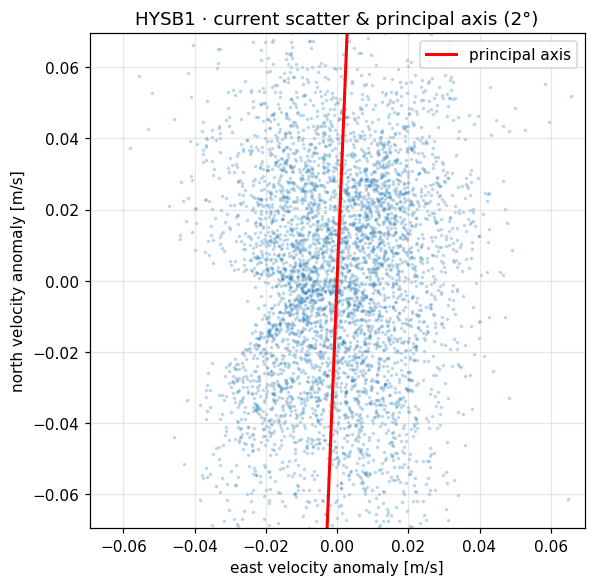

In [3]:
v, orient, u_major = ol.principal_axis(df["east"], df["north"])
print(f"Tidal-current axis orientation: {orient:.0f}° from North "
      f"(unit vector east={v[0]:.2f}, north={v[1]:.2f})")

# show the velocity scatter and the fitted axis
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(df["east"] - df["east"].mean(), df["north"] - df["north"].mean(), s=2, alpha=0.2)
lim = np.nanpercentile(np.abs(np.r_[df["east"]-df["east"].mean(), df["north"]-df["north"].mean()]), 99)
ax.plot([-v[0]*lim, v[0]*lim], [-v[1]*lim, v[1]*lim], "r-", lw=2, label="principal axis")
ax.set_aspect("equal"); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("east velocity anomaly [m/s]"); ax.set_ylabel("north velocity anomaly [m/s]")
ax.legend(); ax.set_title(f"{STATION} · current scatter & principal axis ({orient:.0f}°)")
plt.tight_layout(); ol.savefig(fig, f"06_{STATION}_principal_axis.png"); plt.show()

> 👀 **What you're seeing**
>
> If the cloud is a tilted cigar, the current is strongly polarised along the red axis — a back-and-forth tidal jet. A round blob would mean the current rotates rather than reverses. The axis orientation tells you the compass line the tidal current runs along.

## Step 2 · Eyeball test — overlay the tidal parts

Both signals carry slow non-tidal drift that would obscure the comparison, so we
overlay the **tidal reconstructions** (from `ol.harmonic_fit`) of pressure and of
the along-axis current, each normalised to its own size, for one week.

saved /Users/quakehunter/Documents/data_exploration/figures/06_HYSB1_overlay.png


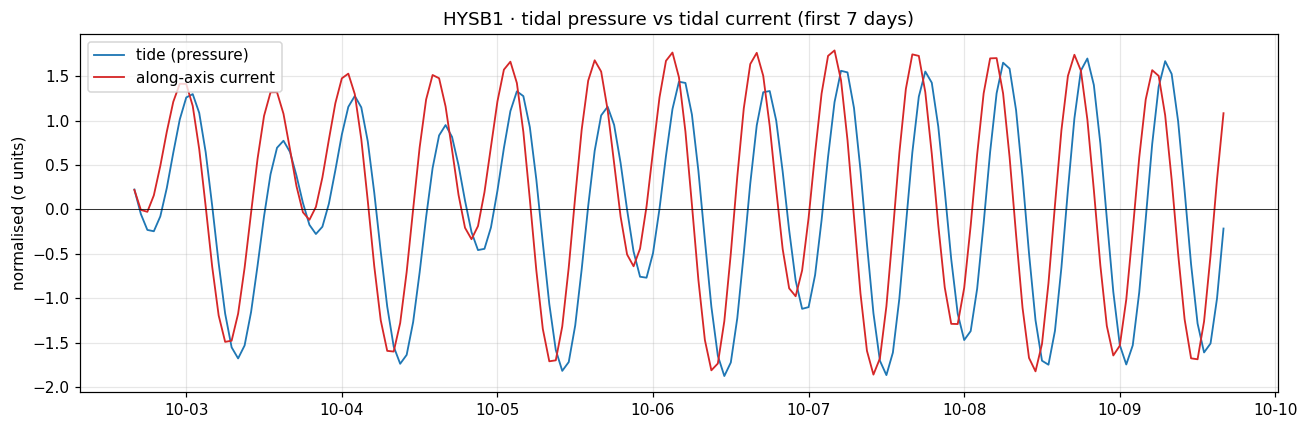

In [4]:
press_tide = ol.harmonic_fit(df["press"])["tide"]
curr_tide  = ol.harmonic_fit(u_major, t0=df.index[0])["tide"]
norm = lambda s: (s - s.mean()) / s.std()

wk = slice(df.index[0], df.index[0] + pd.Timedelta(days=7))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(press_tide.loc[wk].index, norm(press_tide).loc[wk], "C0", lw=1.2, label="tide (pressure)")
ax.plot(curr_tide.loc[wk].index, norm(curr_tide).loc[wk], "C3", lw=1.2, label="along-axis current")
ax.axhline(0, color="k", lw=0.5); ax.legend(); ax.set_ylabel("normalised (σ units)")
ax.set_title(f"{STATION} · tidal pressure vs tidal current (first 7 days)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.tight_layout(); ol.savefig(fig, f"06_{STATION}_overlay.png"); plt.show()

> 👀 **What you're seeing**
>
> Same rhythm, slightly offset: the two curves rise and fall together but their peaks don't land at exactly the same moment. That horizontal offset is the **phase lag** we quantify next. If the red current peaks consistently *before* the blue tide, the current leads.

## Step 3 · Lagged cross-correlation — how big is the time shift?

Slide the current against the tide and see which time shift makes them line up
best. The lag of the highest correlation is the dominant time offset between
them (dominated by the biggest constituent, M2).

saved /Users/quakehunter/Documents/data_exploration/figures/06_HYSB1_crosscorr.png


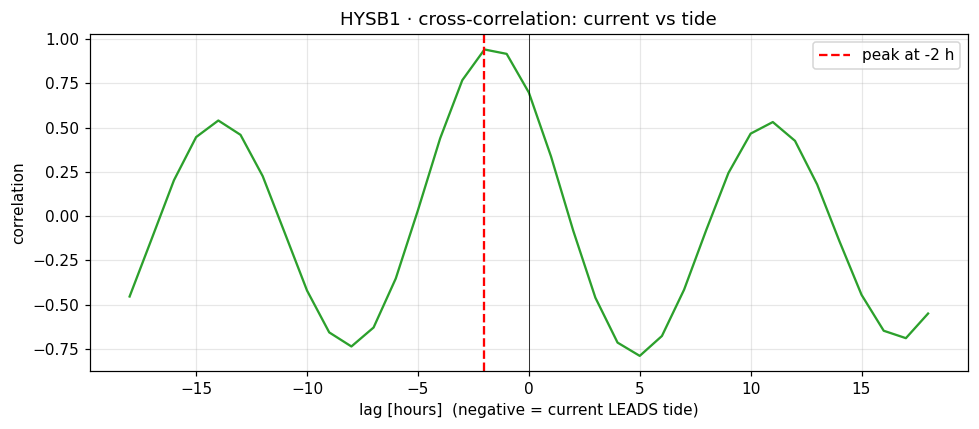

Best alignment at -2 h, correlation 0.94  (current leads the tide).


In [5]:
from scipy.signal import correlate, correlation_lags
x = norm(press_tide); y = norm(curr_tide.reindex(x.index))
m = x.notna() & y.notna(); x, y = x[m].values, y[m].values

corr = correlate(y, x, mode="full") / len(x)
lags = correlation_lags(len(y), len(x), mode="full")     # in hours (hourly data)
keep = np.abs(lags) <= 18                                 # look within ±18 h
k = np.argmax(corr[keep]); best_lag = lags[keep][k]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags[keep], corr[keep], "C2")
ax.axvline(best_lag, color="r", ls="--", label=f"peak at {best_lag:+d} h")
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("lag [hours]  (negative = current LEADS tide)"); ax.set_ylabel("correlation")
ax.legend(); ax.set_title(f"{STATION} · cross-correlation: current vs tide")
plt.tight_layout(); ol.savefig(fig, f"06_{STATION}_crosscorr.png"); plt.show()
print(f"Best alignment at {best_lag:+d} h, correlation {corr[keep][k]:.2f}  "
      f"({'current leads the tide' if best_lag < 0 else 'current lags the tide'}).")

> 👀 **What you're seeing**
>
> A tall, narrow peak near zero lag means a tight, fixed-phase relationship — strong evidence the two are the same forcing. The sign of the peak lag says whether the current runs ahead of or behind the tide.

## Step 4 · Coherence spectrum — *at which frequencies* are they related?

Cross-correlation gives one overall lag; coherence is sharper — it asks, for each
frequency separately, "do these two move together here?" For a tidally-driven
pair we expect coherence to **spike at the diurnal (1/day) and semidiurnal
(2/day) bands** and be low elsewhere.

saved /Users/quakehunter/Documents/data_exploration/figures/06_HYSB1_coherence.png


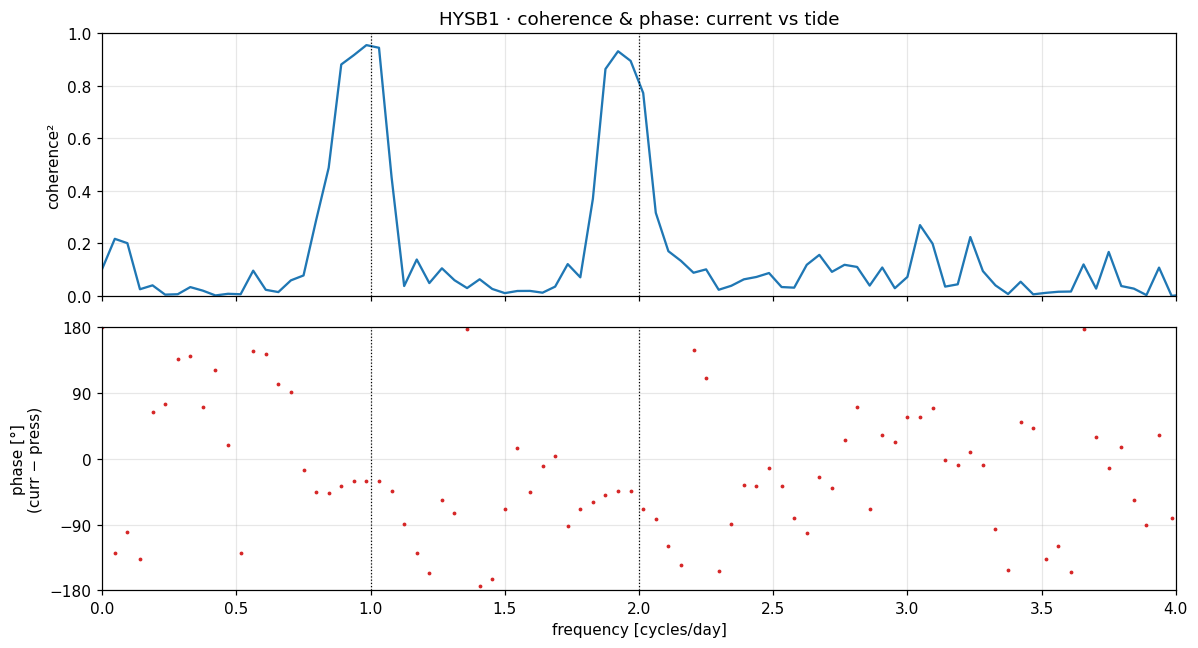

diurnal      (1 cyc/day): coherence²=0.95, phase=-30°
semidiurnal  (2 cyc/day): coherence²=0.77, phase=-69°


In [6]:
from scipy.signal import coherence, csd
fs = 1.0  # cycles/hour
yc = u_major.reindex(df.index).interpolate(limit=3)
xc = df["press"]
f, Cxy = coherence(xc.values, yc.values, fs=fs, nperseg=512)
_, Pxy = csd(yc.values, xc.values, fs=fs, nperseg=512)     # csd(current,press): phase = φ_curr−φ_press
cpd = f * 24                                                # x-axis in cycles/day

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(cpd, Cxy, "C0"); ax1.set_ylabel("coherence²"); ax1.set_ylim(0, 1)
ax2.plot(cpd, np.degrees(np.angle(Pxy)), ".", ms=3, color="C3")
ax2.set_ylabel("phase [°]\n(curr − press)"); ax2.set_ylim(-180, 180); ax2.set_yticks([-180,-90,0,90,180])
for ax in (ax1, ax2):
    for band in (1, 2): ax.axvline(band, color="k", ls=":", lw=0.8)
ax1.set_title(f"{STATION} · coherence & phase: current vs tide")
ax2.set_xlabel("frequency [cycles/day]"); ax2.set_xlim(0, 4)
plt.tight_layout(); ol.savefig(fig, f"06_{STATION}_coherence.png"); plt.show()

for band, fc in [("diurnal", 1/24), ("semidiurnal", 2/24)]:
    i = np.argmin(np.abs(f - fc))
    print(f"{band:12s} ({fc*24:.0f} cyc/day): coherence²={Cxy[i]:.2f}, phase={np.degrees(np.angle(Pxy))[i]:+.0f}°")

> 👀 **What you're seeing**
>
> Coherence should jump close to 1 right at the dotted lines (1 and 2 cycles/day) and sag between them — proof the relationship lives specifically in the tidal bands. The phase panel, read *at those spikes only* (phase is meaningless where coherence is low), gives the lead/lag angle between current and tide at each band.

## Step 5 · Per-constituent phase lag (the precise answer)

Finally, fit the same tidal constituents to **both** signals with a shared time
origin (so phases are comparable) and tabulate, for each constituent:

* the **amplitude ratio** (current per unit tide — an "admittance"),
* the **phase lag** in degrees and in **hours**.

In [7]:
con = ["Q1", "O1", "K1", "N2", "M2", "S2"]
fp = ol.harmonic_fit(df["press"], con)
fc = ol.harmonic_fit(u_major, con, t0=df.index[0])

rows = []
for k in con:
    pa, ca = fp["amps"].loc[k], fc["amps"].loc[k]
    dphi = (ca["phase_deg"] - pa["phase_deg"]) % 360
    dphi = dphi - 360 if dphi > 180 else dphi          # wrap to (-180, 180]
    rows.append({"constituent": k, "period_h": round(pa["period_h"], 2),
                 "tide_amp_dbar": round(pa["amplitude"], 4),
                 "curr_amp_ms": round(ca["amplitude"], 4),
                 "phase_lag_deg": round(dphi, 0),
                 "lag_hours": round(dphi / 360 * pa["period_h"], 2)})
tbl = pd.DataFrame(rows).set_index("constituent")
print("(phase_lag / lag_hours: negative = current LEADS the tide)")
tbl

(phase_lag / lag_hours: negative = current LEADS the tide)


,period_h,tide_amp_dbar,curr_amp_ms,phase_lag_deg,lag_hours
constituent,,,,,
Q1,26.87,0.0447,0.0018,-52.0,-3.87
O1,25.82,0.2487,0.0074,-34.0,-2.43
K1,23.93,0.4159,0.0133,-30.0,-1.99
N2,12.66,0.1786,0.0059,-51.0,-1.78
M2,12.42,0.8436,0.0302,-44.0,-1.51
S2,12.00,0.2415,0.0061,-78.0,-2.59


saved /Users/quakehunter/Documents/data_exploration/figures/06_HYSB1_phase_lag.png


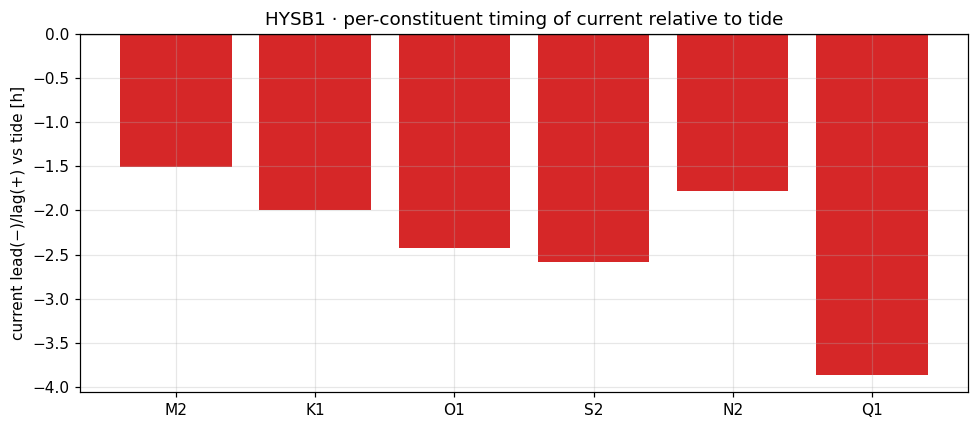

In [8]:
# Visualise the lead/lag of the major constituents
fig, ax = plt.subplots(figsize=(9, 4))
big = tbl.sort_values("tide_amp_dbar", ascending=False)
ax.bar(big.index, big["lag_hours"], color=np.where(big["lag_hours"] < 0, "C3", "C0"))
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("current lead(−)/lag(+) vs tide [h]")
ax.set_title(f"{STATION} · per-constituent timing of current relative to tide")
plt.tight_layout(); ol.savefig(fig, f"06_{STATION}_phase_lag.png"); plt.show()

> 👀 **What you're seeing**
>
> The dominant constituents (M2, K1) should show a consistent, modest lead/lag of a couple of hours — not random values. Consistency across constituents is itself evidence the relationship is real tidal physics. A lag near 0 h would indicate a progressive-wave regime; near ±3 h (≈90° at M2) a standing-wave regime; in between, mixed.

> ✏️ **Try it yourself**
>
> 1. Re-run for another station once its current data lands (`STATION = 'HYS14'`).
> 2. Compare the M2 lag from cross-correlation (Step 3) with the M2 lag in the table (Step 5) — do they agree?
> 3. Project the current onto the MINOR axis instead (use the other eigenvector) — is it coherent with the tide too?
> 4. Repeat the coherence test with TEMPERATURE vs tide instead of current — is temperature tidally coherent here?

> ✅ **Recap**
>
> You combined the two instruments, reduced the current to its tidal axis, and showed they're related four ways: a phased overlay, a sharp cross-correlation peak, high coherence confined to the tidal bands, and consistent per-constituent phase lags. Together these say the currents and the tide are the same forcing — and quantify how the current leads/lags the rise and fall of sea level.
>
> ➡️ **Next:** extend to tidal-current ellipses (fit M2 to east & north separately) or compare lags across stations as more data arrives.